# Modèle GRU

In [1]:
# !pip install tensorflow
#!pip install datasets

In [2]:
import numpy as np
import pandas as pd
import warnings
import os
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
seed = 42

np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

In [3]:
def create_sequences_GRU(X, y, seq_len):    # Cette fonction transforme les données en fenêtres temporelles.
    X_seq, y_seq = [], []

    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i + seq_len])
        y_seq.append(y[i + seq_len])

    return np.array(X_seq), np.array(y_seq).reshape(-1, 1)

In [4]:
def predict_gru(model, X_last, n_steps, future_cov=None):
    """
    Prédiction récursive avec GRU.
    On parle d'une prévision récursive(c est quand le modèle utilise sa propre prédiction pour prédire le pas suivant
    X_last : dernière fenêtre connue, shape = (1, seq_len, n_features)
    n_steps : nombre de pas à prédire
    future_cov : covariables futures, shape = (n_steps, n_cov)
    """

    X_window = X_last.copy()
    preds = []

    for step in range(n_steps):

        # prédiction du prochain pas
        y_pred = model.predict(X_window, verbose=0)[0, 0]
        preds.append(y_pred)

        # décaler la fenêtre vers la gauche
        X_window = np.roll(X_window, -1, axis=1)

        # mettre la prédiction dans la dernière ligne
        # attention : on suppose que la colonne 0 de X est la cible passée
        X_window[0, -1, 0] = y_pred

        # ajouter les covariables futures si elles existent
        if future_cov is not None:
            n_cov = future_cov.shape[1]
            X_window[0, -1, 1:1 + n_cov] = future_cov[step]

    return np.array(preds).reshape(-1, 1)

In [34]:
def fit_gru(
    X_train, y_train,
    X_val=False, y_val=False,
    X_test=False, y_test=False,
    units=64,
    num_layers=1,
    dropout=0.2,
    epochs=50,
    batch_size=32,
    lr=0.001,
    loss="mse",
    patience=10,
    verbose=1,
    seq_len=30
):

    # normalisation
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    y_train_scaled = scaler_y.fit_transform(
        y_train.to_numpy().reshape(-1, 1)
    )

    if type(X_val) != bool:
        X_val_scaled = scaler_X.transform(X_val)
        y_val_scaled = scaler_y.transform(
            y_val.to_numpy().reshape(-1, 1)
        )

    if type(X_test) != bool:
        X_test_scaled = scaler_X.transform(X_test)

    # création des séquences
    X_train_seq, y_train_seq = create_sequences_GRU(
        X_train_scaled, y_train_scaled, seq_len
    )

    if type(X_val) != bool:
        X_val_seq, y_val_seq = create_sequences_GRU(
            X_val_scaled, y_val_scaled, seq_len
        )

    n_features = X_train_seq.shape[2]

    # modèle GRU
    model = models.Sequential()

    if num_layers == 1:
        model.add(layers.GRU(
            units=units,
            input_shape=(seq_len, n_features),
            dropout=dropout
        ))
    else:
        model.add(layers.GRU(
            units=units,
            input_shape=(seq_len, n_features),
            return_sequences=True,
            dropout=dropout
        ))

        for _ in range(num_layers - 2):
            model.add(layers.GRU(
                units=units,
                return_sequences=True,
                dropout=dropout
            ))

        model.add(layers.GRU(
            units=units,
            dropout=dropout
        ))

    model.add(layers.Dense(1))

    # compilation
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=loss
    )

    # callbacks
    callbacks = []

    if type(X_val) != bool:
        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True
        )

        reduce_lr = ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=patience // 2,
            min_lr=1e-6
        )

        callbacks = [early_stop, reduce_lr]

    # entraînement
    model.fit(
        X_train_seq,
        y_train_seq,
        validation_data=(X_val_seq, y_val_seq) if type(X_val) != bool else None,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        shuffle=False,
        verbose=verbose
    )

    # dernière fenêtre connue
    if type(X_val) != bool:
        X_last = X_val_seq[-1:]
    else:
        X_last = X_train_seq[-1:]

    results = {
        "modele_fit": model,
        "scaler_X": scaler_X,
        "scaler_y": scaler_y
    }

    # évaluation sur test
    if type(y_test) != bool:

        n_steps = len(y_test)

        if type(X_test) != bool:
            future_cov = X_test_scaled[:, 1:]
        else:
            future_cov = None

        preds_scaled = predict_gru(
            model,
            X_last,
            n_steps=n_steps,
            future_cov=future_cov
        )

        preds = scaler_y.inverse_transform(preds_scaled)

        y_test_real = y_test.to_numpy().reshape(-1, 1)

        rmse = np.sqrt(mean_squared_error(y_test_real, preds))
        mae = mean_absolute_error(y_test_real, preds)

        results["predictions"] = preds
        results["rmse"] = rmse
        results["mae"] = mae

    return results

## Exemple d'utilisation

In [29]:
# Chargement dataset
def load_wadi_data():
    path = input("Veuillez entrer le chemin complet du fichier CSV : ")
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Base chargée : {df.shape[0]} lignes, {df.shape[1]} colonnes.")
        return df
    else:
        print("Chemin invalide.")
        return None

df = load_wadi_data()

Veuillez entrer le chemin complet du fichier CSV :  C:/Users/abmahamat/Downloads/WADI_clean.csv


Base chargée : 204116 lignes, 124 colonnes.


In [35]:
# Gestion Datetime
if "Datetime" in df.columns:
    df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")
    df = df.dropna(subset=["Datetime"])
    
    df = df.sort_values("Datetime")
    df = df.set_index("Datetime")
else:
    df.index = pd.to_datetime(df.index, errors="coerce")
    df = df[~df.index.isna()]
    df = df.sort_index()

# Régularisation temporelle
df = df.resample("1min").mean(numeric_only=True)
df = df.interpolate().ffill().bfill()

# Cible
target_col = "3_LT_001_PV"

# Toutes les covariables numériques sauf la cible
feature_cols = [
    col for col in df.columns
    if col != target_col
]

# Données modèle
df_model = df[[target_col] + feature_cols].copy()
df_model = df_model.apply(pd.to_numeric, errors="coerce")
df_model = df_model.interpolate().ffill().bfill()

y = df_model[target_col]
X_full = df_model[[target_col] + feature_cols]

In [46]:
train_frac = 0.7
val_frac = 0.15

n_total = len(df_model)

train_end = int(n_total * train_frac)
val_end = int(n_total * (train_frac + val_frac))

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]

X_train = X_full.iloc[:train_end]
X_val = X_full.iloc[train_end:val_end]
X_test_full = X_full.iloc[val_end:]

In [47]:
X_test_for_pred = X_test_full.copy()
X_test_for_pred[target_col] = 0    # on évite d’utiliser la vraie cible future

In [48]:
X_test_for_pred = X_test_full.copy()
X_test_for_pred[target_col] = 0    # on évite d’utiliser la vraie cible future

seq_len = 30

resultat_gru = fit_gru(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test_for_pred,
    y_test=y_test,
    units=64,
    num_layers=1,
    dropout=0.2,
    epochs=50,
    batch_size=32,
    lr=0.001,
    seq_len=seq_len,
    verbose=1
)

print("RMSE :", resultat_gru["rmse"])
print("MAE :", resultat_gru["mae"])

Epoch 1/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0658 - val_loss: 0.0231 - learning_rate: 0.0010
Epoch 2/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0305 - val_loss: 0.0162 - learning_rate: 0.0010
Epoch 3/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0266 - val_loss: 0.0160 - learning_rate: 0.0010
Epoch 4/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0252 - val_loss: 0.0166 - learning_rate: 0.0010
Epoch 5/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0233 - val_loss: 0.0190 - learning_rate: 0.0010
Epoch 6/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0224 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 7/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0220 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 8/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0217 - val_loss: 0.0232 - learning_rate: 0.0010
Epoch 9/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0213 - val_loss: 0.0235 - learning_rate: 5.0000e-

In [49]:
rmse_arima = 1.5186
rmse_gru = 1.106487
skill_score = 1 - (rmse_gru / rmse_arima)
print(f"skill score = {skill_score}")

skill score = 0.2713769261161596


In [45]:
# La fonction predict_gru_simple prépare les données nécessaires à la prédiction, puis appelle la fonction predict_gru, qui réalise 
# effectivement la prédiction récursive pas à pas.

def predict_gru_simple(resultat, der, X_der, n_steps, seq_len, X_test=False, target_col="3_LT_001_PV"):

    if type(X_test) != bool:
        X_test_full = X_test.copy()

        # Si la cible existe déjà, on la met à 0 pour éviter la fuite d'information
        if target_col in X_test_full.columns:
            X_test_full[target_col] = 0
        else:
            X_test_full.insert(0, target_col, 0)

        future_cov = resultat["scaler_X"].transform(X_test_full)
        future_cov = future_cov[:, 1:]
    else:
        future_cov = None

    X_der_scaled = resultat["scaler_X"].transform(X_der)

    y_der_scaled = resultat["scaler_y"].transform(
        der.to_numpy().reshape(-1, 1)
    )

    X_last = create_sequences_GRU(
        X_der_scaled,
        y_der_scaled,
        seq_len
    )[0][-1:]

    preds_scaled = predict_gru(
        resultat["modele_fit"],
        X_last,
        n_steps=n_steps,
        future_cov=future_cov
    )

    return resultat["scaler_y"].inverse_transform(preds_scaled)

In [17]:
# Utilisation

predictions = predict_gru_simple(
    resultat=resultat_gru,
    der=y_val,
    X_der=X_val,
    n_steps=len(y_test),
    seq_len=seq_len,
    X_test=X_test_for_pred
)

predictions[:10]

array([[64.96077 ],
       [65.07428 ],
       [65.1267  ],
       [65.12481 ],
       [65.14153 ],
       [65.12455 ],
       [65.15472 ],
       [65.17075 ],
       [65.11795 ],
       [65.118095]], dtype=float32)

In [18]:
print(y_test[:10].values)
print(predictions[:10])

[64.33180625 64.31201333 64.27636    64.29324375 64.3211     64.26266667
 64.2336875  64.25495333 64.24483125 64.29585333]
[[64.96077 ]
 [65.07428 ]
 [65.1267  ]
 [65.12481 ]
 [65.14153 ]
 [65.12455 ]
 [65.15472 ]
 [65.17075 ]
 [65.11795 ]
 [65.118095]]


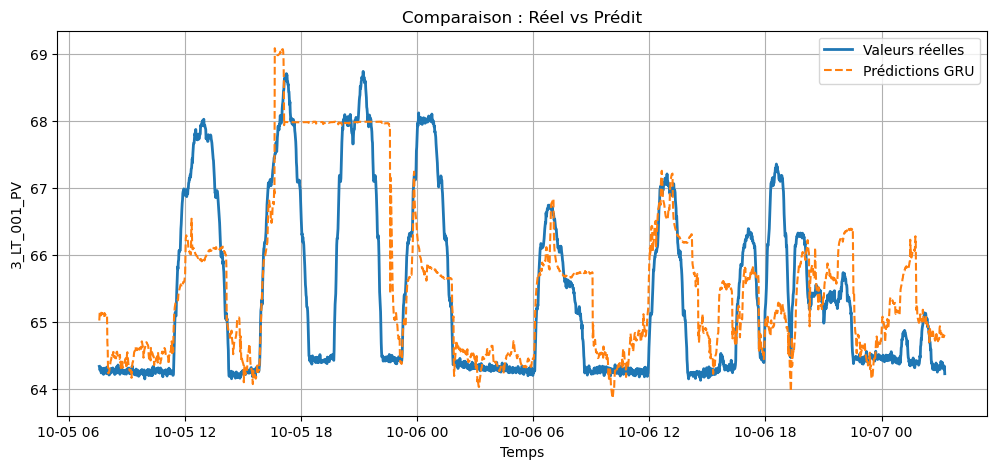

In [50]:
# convertir en format numpy propre
y_true = y_test.to_numpy().reshape(-1)
y_pred = resultat_gru["predictions"].reshape(-1)

plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_true, label="Valeurs réelles", linewidth=2)
plt.plot(y_test.index, y_pred, label="Prédictions GRU", linestyle="--")


plt.title("Comparaison : Réel vs Prédit")
plt.xlabel("Temps")
plt.ylabel("3_LT_001_PV")

plt.legend()
plt.grid()
plt.savefig("gru_predictions.png")
plt.show()

In [56]:
y_true_tab = np.array(y_test)

baseline_pred = None   # 🔥 IMPORTANT

if baseline_pred is None:
    baseline_pred = np.roll(y_true_tab, 1)
    baseline_pred[0] = y_true_tab[0]

In [57]:
def skill_score_gru(y_true, y_pred, baseline_pred=None):
    """
    Skill score du modèle GRU par rapport à un baseline naïf persistant.

    Baseline naïf :
    y_hat(t) = y(t-1)

    SS = 1 - RMSE_model / RMSE_baseline
    """

    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)

    # baseline naïf si non fourni
    if baseline_pred is None:
        baseline_pred = np.roll(y_true, 1)
        baseline_pred[0] = y_true[0]
    else:
        baseline_pred = np.array(baseline_pred).reshape(-1)

    rmse_model = np.sqrt(mean_squared_error(y_true, y_pred))
    rmse_base = np.sqrt(mean_squared_error(y_true, baseline_pred))

    return 1 - (rmse_model / (rmse_base + 1e-8))

In [58]:
y_true = y_test.values
y_pred = resultat_gru["predictions"]

ss_gru = skill_score_gru(y_true, y_pred)

print("Skill Score GRU :", ss_gru)

Skill Score GRU : -15.133395731411717
